# 영상 객체 추적 · 상황 분석 — 설비 동작 상태 분석 (지능형 관제 PoC)

**08 통합 Manifest**까지 개별 신호를 모았다면, 이번에는 교재 **8-5 Video AI Service PoC** 아키텍처를 따라 **검출→추적→상황 추론→검색** 파이프라인을 설비 영상에 적용합니다.

| Part | 주제 |
|------|------|
| 1 | decord/IPAD 영상 수집 · **원본 데이터 시각화** |
| 2 | **YOLOv8** 객체 검출 (Local Detection) |
| 3 | **ByteTrack** 다중 객체 추적 (MOT) |
| 4 | 설비 **동작 구역(ROI)** · 속도·Motion 기반 **상태 분류** |
| 5 | **상황 요약** 에이전트 · 이상 이벤트 트리거 |
| 6 | **ChromaDB** Vector 저장 · 시맨틱 관제 검색 |
| 7 | 관제 대시보드 · MOT/성능 지표 · manifest export |

### PoC 엔드투엔드 파이프라인 

```
CCTV / IPAD 프레임 시퀀스
    ↓ decord 가속 로드 (또는 OpenCV 폴백)
YOLOv8 검출 + ByteTrack ID 유지
    ↓ 구역 이탈 · 속도 급변 · motion z-score
상황 요약 (자연어 리포트)
    ↓ embedding
ChromaDB 시맨틱 검색 + 관제 대시보드
```

02번 **Motion Energy** · 07번 **키포인트 displacement**와 연결: 추적 궤적의 **속도·구역**이 설비 **가동/정지/이상** 상태를 설명합니다.

### IPAD 실습 데이터 (선택)

1. 노트북과 **같은 폴더**에 `IPAD_sample.zip` 배치 (03~07과 동일)
2. zip 없어도 **합성 이동 객체 시퀀스**로 Part 2~7 실행 가능

> **설치:** `ultralytics`(YOLOv8+ByteTrack), `chromadb`, `decord` — 아래 설치 셀 참고. GPU 없으면 CPU로 동작합니다.



### 본 실습에서 다루는 기술

| 기법 | 한 줄 설명 | 코드에서의 역할 |
|------|-----------|----------------|
| **decord** | GPU 가속 비디오/프레임 로드 | `load_video_frames_decord` |
| **YOLOv8** | 실시간 객체 검출 | `get_yolo_model`, `detect_objects` |
| **ByteTrack** | ID 유지 다중 객체 추적 | `track_objects_bytetrack` |
| **ROI Zone** | 설비 동작 허용 구역 | `EQUIPMENT_ZONES`, `check_zone_violation` |
| **Track Velocity** | bbox 중심 이동 속도 | `compute_track_velocity` |
| **Motion Energy** | 프레임 차분 동작 강도 | `compute_motion_energy` |
| **Operation State** | 가동/저활동/이상 분류 | `classify_equipment_state` |
| **Situation Agent** | 추적 이벤트→자연어 요약 | `generate_situation_report` |
| **ChromaDB** | 요약 벡터 저장·검색 | `index_reports_chroma`, `search_reports` |
| **MOT Metrics** | MOTA 근사·ID Switch·FPS | `evaluate_tracking_session` |
| **Tracking Manifest** | 프레임별 추적 JSON | `export_tracking_manifest` |
<br>

decord는 딥러닝·영상 AI용 고속 비디오 디코딩 라이브러리입니다. MXNet 팀에서 만든 오픈소스로, Python에서 mp4 같은 비디오 파일을 프레임 단위로 빠르게 읽어 NumPy 배열로 넘기는 데 쓰입니다.

<br>

#### 용어·기술 상세

| 용어 | 쉬운 설명 |
|------|-----------|
| **MOT** | Multi-Object Tracking — 프레임마다 검출된 객체에 **같은 ID** 유지 |
| **ByteTrack** | 저신뢰 검출도 2차 매칭에 써서 **가림(occlusion)** 에 강한 추적기 |
| **Critical Zone** | 설비 부품·작업물이 **있어야 정상**인 ROI — 이탈 시 이상 후보 |
| **Operation State** | `RUNNING` / `IDLE` / `ANOMALY` 등 설비 동작 상태 라벨 |
| **Situation Report** | 관제원이 읽을 **한국어 상황 문장** (VLM 대체 경량 에이전트) |
| **Vector DB** | 문장을 숫자 벡터로 저장해 **의미 검색** ("컨베이어 정지" 등) |


### 초보자를 위한 기술 이해

이 노트북은 공장·설비 CCTV 영상을 **검출 → 추적 → 상태 판별 → 요약 → 검색** 순서로 처리하는 관제 파이프라인입니다.
- **검출(Detection)**: 각 프레임에서 움직이는 부품이나 객체의 위치(바운딩 박스)를 찾습니다.
- **추적(Tracking)**: 프레임이 바뀌어도 같은 객체에 동일한 **ID**를 붙여 궤적을 만듭니다.
- **상태 분류(State)**: 속도·구역·움직임 강도로 설비가 가동 중인지, 멈췄는지, 이상인지 판단합니다.
- **상황 요약(Summary)**: 수치와 이벤트를 관제원이 읽기 쉬운 한국어 문장으로 바꿉니다.
- **시맨틱 검색(Search)**: 요약 문장을 벡터 DB에 저장해 나중에 자연어로 과거 사건을 찾습니다.
한 장의 사진이 아니라 **시간에 따른 행동**을 이해하는 것이 핵심입니다.



### 기술 설명 — 패키지 설치

| 패키지 | 역할 |
|--------|------|
| `ultralytics` | YOLOv8 검출 + ByteTrack 추적 |
| `chromadb` | 상황 요약 문장의 벡터 저장·검색 (선택) |
| `decord` | mp4 등 비디오 파일 고속 디코딩 (선택) |

이미 `requirements.txt`로 설치했다면 이 셀은 건너뛰어도 됩니다.

### 초보자를 위한 기술 이해

세 패키지는 각각 파이프라인의 다른 구간을 담당하며, 없어도 대체 경로가 있습니다.
- **ultralytics**: YOLOv8 객체 검출과 ByteTrack 추적을 한 번에 제공합니다. 산업 영상에서 범용 객체를 찾을 때 씁니다.
- **chromadb**: 상황 요약 문장을 벡터로 저장·검색하는 경량 DB입니다. 키워드가 달라도 의미가 비슷한 리포트를 찾을 수 있습니다.
- **decord**: mp4 등 비디오를 프레임 단위로 빠르게 읽는 디코더입니다. OpenCV보다 대량 프레임 로드에 유리합니다.
`requirements.txt`로 이미 설치했다면 pip 셀은 건너뛰어도 됩니다.
GPU가 없어도 CPU로 동작하며, 설치 실패 시 motion 기반 폴백·합성 데이터로 나머지 파트를 계속 실습할 수 있습니다.
선택 패키지는 PoC를 **환경에 맞게 단계적으로 확장**하기 위해 분리해 둔 것입니다.


In [1]:
# ── 패키지 설치 (최초 1회, 주석 해제 후 실행) ──
# ultralytics: YOLOv8 검출 + ByteTrack 추적
# chromadb: 상황 요약 문장 벡터 저장·검색 (선택)
# decord: mp4 등 비디오 고속 디코딩 (선택)
# !pip install -q ultralytics chromadb decord



### 기술 설명 — 환경 설정

**이 블록의 역할**  
노트북 전체에서 공유할 **경로, 상수, 선택적 라이브러리 플래그**를 한곳에 모읍니다. 이 셀을 가장 먼저 실행해야 이후 모든 파트가 같은 설정을 사용합니다.

**초보자가 알아두면 좋은 개념**

| 항목 | 쉬운 설명 |
|------|-----------|
| `HAS_DECORD` / `HAS_YOLO` / `HAS_CHROMA` | 해당 패키지가 설치·로드되었는지 여부. `False`면 대체 코드로 자동 폴백 |
| `MAX_FRAMES` / `FRAME_STRIDE` | 실습 속도를 위해 전체 영상 중 일부만 샘플링. stride=2면 2프레임마다 1장 사용 |
| `YOLO_CONF` / `YOLO_IOU` | 검출 신뢰도·겹침 제거 임계값. 높이면 검출 수가 줄고 정밀해짐 |
| `EQUIPMENT_ZONES` | 화면 비율(0~1)로 정의한 **관심 구역(ROI)**. 설비 부품이 있어야 할 영역 |
| `VELOCITY_*_THRESH` | 추적 대상이 프레임마다 얼마나 움직였는지로 가동/정지를 나누는 기준 |
| `OUTPUT_DIR` | 그림·JSON·DB 결과가 저장되는 폴더 |

**왜 선택 의존성을 try/except로 불러오나?**  
Colab, Windows, GPU 유무 등 환경마다 설치 패키지가 다릅니다. 한 라이브러리가 없어도 **나머지 파이프라인은 계속 돌아가게** 하기 위함입니다.

> 차트 한글이 깨지면 `setup_korean_font()`의 OS별 폰트 설정을 확인하세요.

### 초보자를 위한 기술 이해

설정 셀은 노트북 전체가 공유하는 **스위치와 기준값**을 모아 둔 곳입니다.
- `HAS_YOLO`, `HAS_DECORD`, `HAS_CHROMA`: 패키지 로드 성공 여부입니다. `False`면 해당 기능 없이 폴백 코드가 실행됩니다.
- `MAX_FRAMES`, `FRAME_STRIDE`: 전체 영상 중 일부만 샘플링해 실습 시간을 줄입니다.
- `YOLO_CONF`, `YOLO_IOU`: 검출 신뢰도와 겹침 제거 기준입니다. 높이면 오검출은 줄지만 놓치는 객체도 늘 수 있습니다.
- `EQUIPMENT_ZONES`: 화면 비율(0~1)로 정의한 **관심 구역(ROI)** 입니다. 부품이 있어야 할 영역과 대기 구역을 나눕니다.
- `VELOCITY_*_THRESH`: 추적 대상이 프레임마다 얼마나 움직였는지로 가동·정지를 구분하는 속도 임계값입니다.
상수를 한곳에 모아 두면 파트마다 값을 바꿀 필요 없이 실험 조건을 통일할 수 있습니다.


In [2]:
from __future__ import annotations

# =============================================================================
# 환경 설정 — import, IPAD/출력 경로, YOLO·ByteTrack·관제 파라미터
# =============================================================================
# 노트북 전체에서 공유하는 경로·상수·라이브러리 플래그를 정의합니다.
# 반드시 다른 코드 셀보다 먼저 실행하세요.

import json
import os
import platform
import re
import time
import uuid
import zipfile
from collections import defaultdict
from dataclasses import dataclass, field
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from scipy.ndimage import gaussian_filter

# ── 선택 의존성 ─────────────────────────────────────────────────────────────
# 아래 패키지는 환경에 따라 없을 수 있으므로 try/except로 안전하게 import 합니다.
try:
    from decord import VideoReader, cpu  # 비디오 파일 고속 디코딩 (mp4 등)
    HAS_DECORD = True
except ImportError:
    HAS_DECORD = False  # 없으면 IPAD jpg 시퀀스·OpenCV만으로 진행

YOLO = None  # lazy import — torch/ultralytics 환경 오류 시 motion tracker 폴백
try:
    from ultralytics import YOLO as _YOLO
    YOLO = _YOLO
    HAS_YOLO = True
except Exception:
    HAS_YOLO = False  # 없으면 Part 3에서 SimpleByteTracker 사용

try:
    import chromadb  # noqa: F401 — USE_CHROMA=1 일 때 Part 6에서 사용
    HAS_CHROMA = True
except Exception:
    HAS_CHROMA = False  # 없으면 인메모리 벡터 검색으로 대체

# ── 입력 데이터(IPAD) ─────────────────────────────────────────────────────────
# IPAD 산업 이상 탐지 데이터셋 — zip 또는 압축 해제 폴더 이름
IPAD_ZIP_NAMES = ("IPAD_sample.zip", "IPAD_Sample.zip")
IPAD_SEARCH_PATHS = [Path("IPAD_Sample"), Path("IPAD_sample")]
FRAME_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}  # 프레임 이미지 확장자

# ── 출력 경로 ─────────────────────────────────────────────────────────────────
OUTPUT_DIR = Path("output_tracking")
FIG_DIR = OUTPUT_DIR / "figures"       # 대시보드·원본 시각화 PNG
PRED_DIR = OUTPUT_DIR / "predictions"  # 검출·추적 오버레이 이미지
CHROMA_DIR = OUTPUT_DIR / "chroma_db"
MANIFEST_PATH = OUTPUT_DIR / "tracking_manifest.json"
SAMPLE_DIR = OUTPUT_DIR / "samples"

# ── 영상 로드 ─────────────────────────────────────────────────────────────────
MAX_FRAMES = 48      # 실습에 사용할 최대 프레임 수 (늘리면 정확도↑, 시간↑)
FRAME_STRIDE = 2     # N프레임마다 1장 샘플링 (2 → 0,2,4,... 번 프레임)
FPS_ASSUMED = 10.0   # 초 단위 타임스탬프 환산용 가정 FPS

# ── YOLO / ByteTrack ──────────────────────────────────────────────────────────
YOLO_MODEL_NAME = "yolov8n.pt"   # nano 모델: 가볍고 빠름 (실무는 s/m/l 선택)
YOLO_CONF = 0.25                 # 검출 confidence 하한 (낮을수록 검출 많음)
YOLO_IOU = 0.45                  # NMS IoU 임계값 — 겹치는 박스 제거
TRACKER_NAME = "bytetrack.yaml"
# 산업 설비에서 관심 있을 COCO 클래스 (person, truck, car 등)
TRACK_CLASS_NAMES = {"person", "truck", "car", "bus", "motorcycle", "bicycle"}

# ── 설비 동작 구역 (프레임 비율 0~1) ─────────────────────────────────────────
# x1,y1,x2,y2 — IPAD 설비 영상 중앙 작업 구역 예시
# 좌표는 픽셀이 아니라 화면 비율이므로 해상도가 바뀌어도 같은 위치를 가리킵니다.
EQUIPMENT_ZONES = {
    "operation_zone": (0.20, 0.25, 0.80, 0.85),  # 정상 작업이 일어나야 하는 영역
    "idle_zone": (0.02, 0.55, 0.18, 0.95),       # 대기·보조 영역 (참고용)
}
ZONE_VIOLATION_FRAMES = 2  # 연속 N프레임 이탈 시 이상

# ── 동작 상태 임계값 ───────────────────────────────────────────────────────────
VELOCITY_RUN_THRESH = 3.5       # px/frame — 가동 중
VELOCITY_IDLE_THRESH = 0.8      # px/frame — 정지 근처
MOTION_Z_ANOMALY = 2.2          # motion energy z-score
MIN_TRACK_HITS = 3              # YOLO 추적 결과가 너무 적으면 simple tracker로 폴백

# ── IPAD 컨베이어 부품 motion 검출 (COCO YOLO 대체) ───────────────────────────
# IPAD 영상은 COCO 클래스(사람·차량)가 거의 없어 프레임 차분으로 움직이는 부품을 찾습니다.
MOTION_DIFF_THRESH = 10         # 이전/다음 프레임 차이 픽셀값 하한 — 노이즈 제거
MOTION_MIN_AREA = 80            # blob 최소 면적(px²) — 너무 작은 점 무시
MOTION_MAX_AREA_RATIO = 0.12    # 화면 대비 blob 최대 면적 비율 — 배경 전체 변화 방지
MOTION_MAX_BLOBS = 12           # 프레임당 최대 motion 검출 수

# ── Chroma / 요약 ─────────────────────────────────────────────────────────────
CHROMA_COLLECTION = "equipment_situation_reports"
EMBED_DIM = 384

# 출력 폴더가 없으면 미리 생성해 이후 셀에서 저장 오류를 방지합니다.
for d in (OUTPUT_DIR, FIG_DIR, PRED_DIR, SAMPLE_DIR, CHROMA_DIR):
    d.mkdir(parents=True, exist_ok=True)


def _search_roots() -> list[Path]:
    """IPAD zip·폴더를 찾을 때 탐색할 루트 경로 목록."""
    roots = [Path.cwd(), Path(".")]
    try:
        roots.append(Path(__file__).resolve().parent)
    except NameError:
        pass  # Jupyter 노트북에서는 __file__이 없을 수 있음
    return list(dict.fromkeys(roots))


def setup_korean_font() -> None:
    """matplotlib 차트 제목·축에 한글이 깨지지 않도록 OS별 폰트 설정."""
    if platform.system() == "Windows":
        plt.rcParams["font.family"] = "Malgun Gothic"
    elif platform.system() == "Darwin":
        plt.rcParams["font.family"] = "AppleGothic"
    else:
        plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["axes.unicode_minus"] = False


setup_korean_font()
print(
    f"환경 설정 완료 | decord={HAS_DECORD} | yolo={HAS_YOLO} | chroma={HAS_CHROMA}"
)

# =============================================================================
# IPython 시각화 헬퍼 — 노트북 setup 셀에서 분리한 표시 유틸
# =============================================================================
# OpenCV BGR 이미지를 matplotlib·Jupyter 출력으로 보여주는 함수 모음입니다.
# setup.py 실행 후 이 셀을 실행하면 Part 3 등에서 show_image_bgr 등을 사용할 수 있습니다.

from IPython.display import display

import cv2
import matplotlib.pyplot as plt
import numpy as np


def bgr_to_rgb(img_bgr: np.ndarray) -> np.ndarray:
    """OpenCV BGR → matplotlib RGB."""
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def pick_timeline_indices(num_frames: int, n_show: int = 8) -> list[int]:
    """클립 전체를 대표하는 균등 간격 프레임 인덱스."""
    if num_frames <= 0:
        return []
    if num_frames <= n_show:
        return list(range(num_frames))
    return [int(round(i * (num_frames - 1) / (n_show - 1))) for i in range(n_show)]


def show_figure(fig) -> None:
    """matplotlib Figure를 노트북 셀 출력으로 표시."""
    display(fig)


def show_image_bgr(img_bgr: np.ndarray, title: str = "", figsize: tuple[float, float] = (5.0, 4.0)) -> None:
    """단일 BGR 이미지를 노트북에 표시."""
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(bgr_to_rgb(img_bgr))
    if title:
        ax.set_title(title)
    ax.axis("off")
    fig.tight_layout()
    show_figure(fig)
    plt.close(fig)


def show_images_grid_bgr(
    images: list[np.ndarray],
    titles: list[str] | None = None,
    ncols: int = 4,
    figsize_per_col: float = 2.8,
) -> None:
    """여러 BGR 이미지를 격자로 노트북에 표시."""
    if not images:
        return
    n = len(images)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_col * ncols, figsize_per_col * nrows))
    axes = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < n:
            ax.imshow(bgr_to_rgb(images[i]))
            if titles and i < len(titles):
                ax.set_title(titles[i], fontsize=9)
    fig.tight_layout()
    show_figure(fig)
    plt.close(fig)


def show_side_by_side_bgr(left: np.ndarray, right: np.ndarray, left_title: str, right_title: str) -> None:
    """원본 | 결과 2열 비교 출력."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(bgr_to_rgb(left))
    axes[0].set_title(left_title)
    axes[0].axis("off")
    axes[1].imshow(bgr_to_rgb(right))
    axes[1].set_title(right_title)
    axes[1].axis("off")
    fig.tight_layout()
    show_figure(fig)
    plt.close(fig)


환경 설정 완료 | decord=False | yolo=True | chroma=True


## Part 1 — 영상 수집 · IPAD/decord 로드

| 단계 | 교재 PoC | 본 실습 |
|------|----------|---------|
| Data Ingestion | CCTV + decord 다운샘플링 | IPAD 프레임 시퀀스 또는 합성 영상 |
| 출력 | 프레임 배열 + 메타 | `frame_paths`, `frames_bgr` |

<br>

> **한 줄 요약:** IPAD 클립이 있으면 decord/OpenCV로 읽고, 없으면 **이동 사각형 합성 시퀀스**로 추적 파이프라인을 검증합니다.


### 기술 설명 — 영상 수집

**비디오를 어떻게 읽나?**  
실무 CCTV는 **연속 프레임 스트림**입니다. 본 실습은 IPAD 데이터셋처럼 `000.jpg, 001.jpg, ...` 형태의 **이미지 시퀀스**를 영상처럼 다룹니다.

**핵심 함수**

| 함수 | 하는 일 |
|------|---------|
| `ensure_ipad_sample()` | zip이 있으면 풀고, 이미 풀린 폴더면 그대로 사용 |
| `load_ipad_clip_frames()` | 설비 클립에서 프레임 경로 목록 수집 |
| `read_image_bgr()` | Windows 한글 경로에서도 이미지를 안전하게 읽기 (`imdecode`) |
| `make_synthetic_equipment_sequence()` | IPAD가 없을 때 이동 사각형 합성 영상 생성 |

**출력 변수**  
- `frames_bgr`: OpenCV가 읽는 **BGR** 순서의 numpy 이미지 리스트  
- `frame_paths`: 각 프레임 파일 경로 (합성이면 빈 리스트)  
- `source_label`: `"IPAD"` 또는 `"synthetic"`

### 초보자를 위한 기술 이해

컴퓨터가 보는 영상은 결국 **연속된 이미지(프레임) 목록**입니다. IPAD 데이터는 `000.jpg, 001.jpg, …`처럼 이미지 시퀀스로 제공됩니다.
- **BGR**: OpenCV는 픽셀 색 순서를 Blue-Green-Red로 읽습니다. 화면에 보여 줄 때는 RGB로 변환하는 경우가 많습니다.
- **IPAD 실습 데이터**: 실제 설비 클립에서 뽑은 프레임으로, motion 기반 검출·추적에 맞춰져 있습니다.
- **합성(synthetic) 시퀀스**: zip이 없을 때 코드가 움직이는 사각형 영상을 만들어 파이프라인 전체를 검증합니다.
decord가 있으면 mp4도 같은 방식으로 프레임 배열로 바꿀 수 있고, 없으면 OpenCV·jpg 시퀀스로 진행합니다.
`frames_bgr`는 처리용 이미지 배열, `frame_paths`는 원본 파일 경로, `source_label`은 데이터 출처를 나타냅니다.
Part 2 이후 모든 함수는 이 리스트를 **시간 순서가 있는 영상**으로 다룹니다.


In [3]:
# =============================================================================
# Part 1 — IPAD 탐색 · decord/OpenCV 프레임 로드 · 합성 폴백
# =============================================================================
# [출력] frames_bgr(이미지 배열), frame_paths(경로), source_label(IPAD|synthetic)


def find_ipad_zip() -> Path | None:
    """노트북 폴더에서 IPAD_sample.zip 파일을 탐색합니다."""
    for root in _search_roots():
        for name in IPAD_ZIP_NAMES:
            p = root / name
            if p.is_file():
                return p
        try:
            # 대소문자 다른 zip 이름도 stem으로 매칭
            for f in root.iterdir():
                if f.is_file() and f.suffix.lower() == ".zip" and f.stem.lower() == "ipad_sample":
                    return f
        except OSError:
            continue
    return None


def ensure_ipad_sample() -> Path | None:
    """압축 해제된 IPAD_Sample/ 가 있으면 반환, 없으면 zip 해제를 시도합니다."""
    for root in _search_roots():
        for rel in IPAD_SEARCH_PATHS:
            base = root / rel
            if base.is_dir():
                return base
    z = find_ipad_zip()
    if z is None:
        return None
    target = z.parent / "IPAD_Sample"
    if not target.is_dir():
        with zipfile.ZipFile(z, "r") as zf:
            zf.extractall(z.parent)
    for rel in IPAD_SEARCH_PATHS:
        base = z.parent / rel
        if base.is_dir():
            return base
    return None


def _list_frame_files(folder: Path) -> list[Path]:
    """한 클립 폴더 안의 이미지 파일만 정렬해 반환."""
    return sorted(p for p in folder.iterdir() if p.suffix.lower() in FRAME_EXTS)


def load_ipad_clip_frames(max_frames: int = MAX_FRAMES, stride: int = FRAME_STRIDE) -> list[Path]:
    """testing 클립 우선, 없으면 training에서 프레임 경로를 stride 간격으로 샘플링."""
    root = ensure_ipad_sample()
    if root is None:
        return []
    candidates: list[Path] = []
    # testing → training 순으로 frames/ 하위 클립 탐색
    for split in ("testing", "training"):
        for frames_root in root.rglob("frames"):
            if split not in str(frames_root):
                continue
            for clip_dir in sorted(frames_root.iterdir()):
                if clip_dir.is_dir():
                    candidates.extend(_list_frame_files(clip_dir))
                    if candidates:
                        break
            if candidates:
                break
        if candidates:
            break
    if not candidates:
        candidates = sorted(p for p in root.rglob("*") if p.suffix.lower() in FRAME_EXTS)
    sampled = candidates[:: max(1, stride)][:max_frames]
    # 깨진 IPAD(0바이트 jpg) 방어 — imread 대신 파일 크기만 검사
    valid = [p for p in sampled if p.is_file() and p.stat().st_size > 512]
    return valid


def read_image_bgr(path: Path | str) -> np.ndarray:
    # cv2.imread는 Windows 한글 경로에서 실패할 수 있어 fromfile + imdecode 사용
    buf = np.fromfile(str(path), dtype=np.uint8)
    img = cv2.imdecode(buf, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"이미지 로드 실패: {path}")
    return img


def write_image_bgr(path: Path | str, img: np.ndarray) -> None:
    """BGR 이미지를 한글 경로에도 안전하게 저장."""
    ok, buf = cv2.imencode(pathlib_suffix(path), img)
    if not ok:
        raise RuntimeError(f"이미지 인코딩 실패: {path}")
    buf.tofile(str(path))


def pathlib_suffix(path: Path | str) -> str:
    """저장 확장자 정규화 — .jpeg는 .jpg로 통일."""
    s = Path(path).suffix.lower()
    return ".jpg" if s in ("", ".jpeg") else s


def load_frames_from_paths(paths: list[Path]) -> list[np.ndarray]:
    """경로 리스트를 BGR numpy 배열 리스트로 변환."""
    return [read_image_bgr(p) for p in paths]


def load_video_frames_decord(video_path: Path, max_frames: int = MAX_FRAMES, stride: int = FRAME_STRIDE) -> list[np.ndarray]:
    """mp4 등 비디오 파일에서 decord로 프레임 배치 로드 (IPAD jpg 시퀀스와 별도)."""
    if not HAS_DECORD or not video_path.is_file():
        return []
    vr = VideoReader(str(video_path), ctx=cpu(0))
    idxs = list(range(0, min(len(vr), max_frames * stride), stride))[:max_frames]
    batch = vr.get_batch(idxs).asnumpy()
    return [cv2.cvtColor(f, cv2.COLOR_RGB2BGR) for f in batch]


def make_synthetic_equipment_sequence(
    num_frames: int = MAX_FRAMES,
    size: int = 640,
) -> list[np.ndarray]:
    """설비 컨베이어 위 이동 부품을 시뮬레이션 — YOLO 없이도 추적·구역 실습 가능."""
    frames: list[np.ndarray] = []
    cx, cy = int(size * 0.25), int(size * 0.55)
    for i in range(num_frames):
        canvas = np.full((size, size, 3), 32, dtype=np.uint8)
        # 배경 설비 프레임 느낌
        cv2.rectangle(canvas, (40, 80), (size - 40, size - 60), (55, 55, 60), -1)
        cv2.rectangle(canvas, (int(size * 0.2), int(size * 0.25)), (int(size * 0.8), int(size * 0.85)), (70, 90, 70), 1)
        # 이동 부품 — phase에 따라 x 위치 변경 (추적·속도 실습용)
        phase = i / max(1, num_frames - 1)
        if phase < 0.75:
            cx = int(size * (0.22 + 0.55 * phase))
        else:
            cx = int(size * 0.62)
        cy = int(size * 0.55 + 8 * np.sin(i * 0.35))
        cv2.rectangle(canvas, (cx - 28, cy - 18), (cx + 28, cy + 18), (40, 180, 220), -1)
        cv2.putText(canvas, f"frame {i}", (12, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (220, 220, 220), 1)
        frames.append(canvas)
    return frames


# ── 실행: IPAD 우선 로드, 실패·부재 시 합성 시퀀스 ──
ipad_paths = load_ipad_clip_frames()
if ipad_paths:
    try:
        source_label = "IPAD"
        frame_paths = ipad_paths
        frames_bgr = load_frames_from_paths(frame_paths)
        print(f"[Part 1] IPAD 프레임 {len(frames_bgr)}장 로드")
    except Exception as exc:
        print(f"[Part 1] IPAD load failed, synthetic fallback: {exc}")
        source_label = "synthetic"
        frame_paths = []
        frames_bgr = make_synthetic_equipment_sequence()
else:
    source_label = "synthetic"
    frame_paths = []
    frames_bgr = make_synthetic_equipment_sequence()
    print(f"[Part 1] 합성 설비 시퀀스 {len(frames_bgr)}프레임 생성")

h0, w0 = frames_bgr[0].shape[:2]
print(f"  해상도: {w0}x{h0} | decord 사용 가능: {HAS_DECORD}")


[Part 1] IPAD 프레임 48장 로드
  해상도: 256x256 | decord 사용 가능: False


### Part 1-A — 원본 데이터 시각화

로드한 **원본 프레임 시퀀스**를 먼저 눈으로 확인합니다. 추적·상태 분류 전에 **원본 영상 품질**·동작 리듬·구역(ROI) 위치를 점검하는 단계입니다. 잘못된 데이터로는 아무리 좋은 모델도 의미 있는 결과를 내기 어렵습니다.

| 시각화 | 설명 | 읽는 법 |
|--------|------|---------|
| 타임라인 그리드 | 전체 클립에서 균등 간격 **8프레임** 미리보기 | 동작이 보이는지, 흔들림·가림은 없는지 |
| Motion Energy | 인접 두 프레임 픽셀 차이 평균 — 설비 **움직임 강도** 1차 신호 (02번과 동일 개념) | 값이 주기적으로 오르내리면 반복 동작, 평평하면 정지 구간 |
| ROI 오버레이 | 설비 **operation_zone** · **idle_zone** 위치 확인 | 초록 `operation_zone` 안에서 설비가 움직이는지 |

<br>

> 저장: `output_tracking/figures/01_source_overview.png`

### 초보자를 위한 기술 이해

추적·분류 전에 원본 영상을 **눈으로 확인**하는 이유는, 잘못된 입력은 이후 단계 전체를 망가뜨리기 때문입니다.
- 타임라인 그리드로 흔들림·가림·노출 문제를 빠르게 점검합니다.
- **ROI(관심 구역)**: 설비가 움직여야 하는 `operation_zone`과 대기 `idle_zone`이 화면 어디에 그려졌는지 확인합니다.
- **Motion Energy**: 인접 두 프레임의 픽셀 차이 평균으로 **움직임 강도**를 1차 추정합니다. 값이 주기적으로 오르내리면 반복 동작, 평평하면 정지 구간입니다.
02번 노트북의 motion energy와 같은 개념이므로, 이후 z-score·상태 분류의 **기준 신호**가 됩니다.
시각화는 모델 성능 문제인지, 카메라·구역 설정 문제인지 구분하는 첫 단계입니다.
결과는 `01_source_overview.png`로 저장되어 나중에 보고서에 그대로 첨부할 수 있습니다.


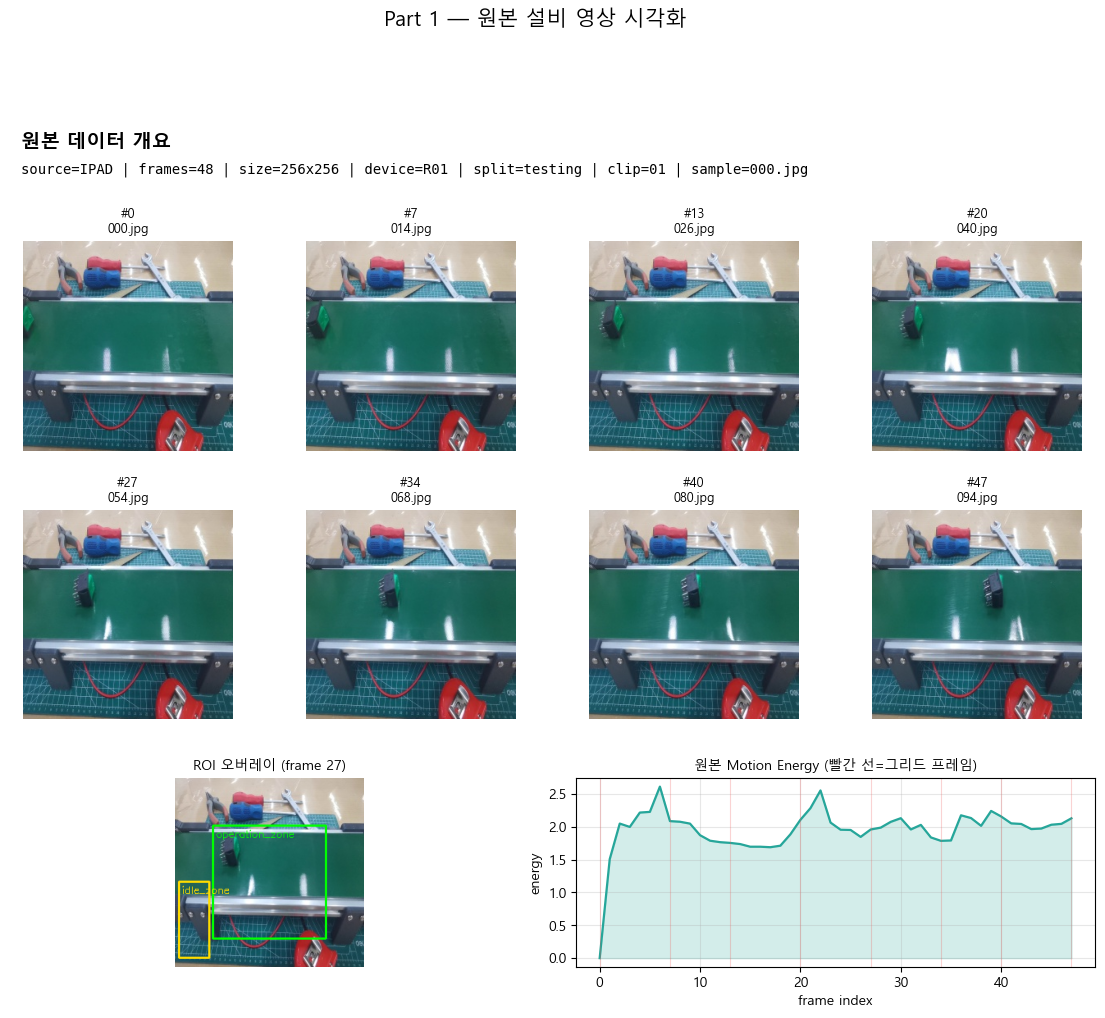

[Part 1-A] 원본 시각화 저장: output_tracking\figures\01_source_overview.png


In [4]:
# =============================================================================
# Part 1-A — 원본 데이터 시각화
# =============================================================================
# 추적·분류 전 원본 품질·동작 리듬·ROI 위치를 눈으로 확인합니다.


def bgr_to_rgb(img_bgr: np.ndarray) -> np.ndarray:
    """setup 셀과 동일 유틸 — OpenCV BGR을 matplotlib RGB로 변환."""
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def resolve_clip_meta(paths: list[Path]) -> dict:
    """IPAD 경로에서 설비·split·clip_id 메타 추출. 합성 데이터면 synthetic 표기."""
    if not paths:
        return {"source": source_label, "device": "-", "split": "-", "clip_id": "-"}
    p = Path(paths[0])
    parts = [x.lower() for x in p.parts]
    meta = {"source": source_label, "device": "-", "split": "-", "clip_id": p.parent.name}
    if "training" in parts:
        meta["split"] = "training"
    elif "testing" in parts:
        meta["split"] = "testing"
    for i, name in enumerate(parts):
        if name in ("training", "testing") and i > 0:
            meta["device"] = parts[i - 1].upper()
            break
    return meta


def pick_timeline_indices(num_frames: int, n_show: int = 8) -> list[int]:
    """setup 셀과 동일 유틸 — 클립 전체를 대표하는 균등 간격 프레임 인덱스 (첫·끝 포함)."""
    if num_frames <= 0:
        return []
    if num_frames <= n_show:
        return list(range(num_frames))
    return [int(round(i * (num_frames - 1) / (n_show - 1))) for i in range(n_show)]


def draw_zones_on_frame(frame_bgr: np.ndarray) -> np.ndarray:
    """EQUIPMENT_ZONES를 픽셀 좌표로 변환해 프레임에 그립니다."""
    vis = frame_bgr.copy()
    h, w = vis.shape[:2]
    for name, zone in EQUIPMENT_ZONES.items():
        x1, y1, x2, y2 = zone
        px1, py1 = int(x1 * w), int(y1 * h)
        px2, py2 = int(x2 * w), int(y2 * h)
        color = (0, 255, 0) if name == "operation_zone" else (0, 220, 255)
        cv2.rectangle(vis, (px1, py1), (px2, py2), color, 2)
        cv2.putText(vis, name, (px1 + 4, py1 + 16), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)
    return vis


def compute_motion_energy_preview(frames: list[np.ndarray]) -> np.ndarray:
    """연속 프레임 그레이스케일 차이 평균 = 프레임별 움직임 강도 (02번과 동일 개념)."""
    energies = [0.0]
    for i in range(1, len(frames)):
        g0 = cv2.cvtColor(frames[i - 1], cv2.COLOR_BGR2GRAY).astype(np.float32)
        g1 = cv2.cvtColor(frames[i], cv2.COLOR_BGR2GRAY).astype(np.float32)
        energies.append(float(np.mean(np.abs(g1 - g0))))
    return np.array(energies, dtype=np.float32)


def plot_source_overview(
    frames: list[np.ndarray],
    paths: list[Path],
    label: str,
    save_path: Path,
    n_grid: int = 8,
) -> None:
    """메타 + 8프레임 그리드 + ROI + motion 곡선을 한 장의 보고서 PNG로 저장."""
    meta = resolve_clip_meta(paths)
    motion_prev = compute_motion_energy_preview(frames)
    idxs = pick_timeline_indices(len(frames), n_show=n_grid)

    fig = plt.figure(figsize=(14, 11))
    gs = GridSpec(4, 4, figure=fig, height_ratios=[0.3, 1, 1, 0.9], hspace=0.35, wspace=0.2)

    # 상단 메타 정보
    ax_meta = fig.add_subplot(gs[0, :])
    ax_meta.axis("off")
    path_hint = str(paths[0].name) if paths else "(synthetic sequence)"
    meta_text = (
        f"source={label} | frames={len(frames)} | size={frames[0].shape[1]}x{frames[0].shape[0]} | "
        f"device={meta['device']} | split={meta['split']} | clip={meta['clip_id']} | sample={path_hint}"
    )
    ax_meta.text(0.01, 0.55, "원본 데이터 개요", fontsize=14, fontweight="bold")
    ax_meta.text(0.01, 0.15, meta_text, fontsize=10, family="monospace")

    # 타임라인 그리드 (2행 x 4열 = 8프레임)
    for j, fi in enumerate(idxs):
        row, col = divmod(j, 4)
        ax = fig.add_subplot(gs[1 + row, col])
        ax.imshow(bgr_to_rgb(frames[fi]))
        title = f"#{fi}"
        if paths and fi < len(paths):
            title += f"\n{paths[fi].name}"
        ax.set_title(title, fontsize=9)
        ax.axis("off")

    # ROI 오버레이 (중간 프레임)
    mid = idxs[len(idxs) // 2]
    ax_roi = fig.add_subplot(gs[3, 0:2])
    ax_roi.imshow(bgr_to_rgb(draw_zones_on_frame(frames[mid])))
    ax_roi.set_title(f"ROI 오버레이 (frame {mid})", fontsize=10)
    ax_roi.axis("off")

    # Motion Energy 미리보기
    ax_m = fig.add_subplot(gs[3, 2:4])
    ax_m.plot(np.arange(len(motion_prev)), motion_prev, color="#26a69a", lw=1.6)
    ax_m.fill_between(np.arange(len(motion_prev)), motion_prev, alpha=0.2, color="#26a69a")
    for fi in idxs:
        ax_m.axvline(fi, color="#ef5350", alpha=0.25, lw=0.8)
    ax_m.set_title("원본 Motion Energy (빨간 선=그리드 프레임)", fontsize=10)
    ax_m.set_xlabel("frame index")
    ax_m.set_ylabel("energy")
    ax_m.grid(alpha=0.3)

    fig.suptitle("Part 1 — 원본 설비 영상 시각화", fontsize=15, y=0.98)
    fig.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.show()
    plt.close(fig)


overview_path = FIG_DIR / "01_source_overview.png"
plot_source_overview(frames_bgr, frame_paths, source_label, overview_path)
print(f"[Part 1-A] 원본 시각화 저장: {overview_path}")


## Part 2 — YOLOv8 객체 검출 (Local Detection)

교재 **Local Detection** 단계: YOLOv8로 프레임 패치를 고속 분석합니다.

- 산업 영상에서는 COCO 클래스가 제한적일 수 있습니다 → **motion blob 보조 검출** 포함
- 검출 결과는 Part 3 ByteTrack 입력


### 기술 설명 — 객체 검출 (YOLOv8)

**검출(Detection)** 은 한 장의 이미지에서 “무엇이 어디에 있는가?”를 찾는 단계입니다. 결과는 보통 **바운딩 박스(bbox)** 와 **클래스 이름**입니다.

**산업 영상의 현실**  
YOLOv8은 COCO(사람·차량 등)로 학습되어, **컨베이어 부품** 같은 IPAD 객체는 검출하지 못합니다. 그래서 IPAD(`source_label == "IPAD"`)에서는 **operation_zone ROI 내 motion blob**(프레임 차분)을 **주 검출**로 사용합니다.

| `Detection` 필드 | 의미 |
|------------------|------|
| `bbox` | (x1,y1,x2,y2) 픽셀 좌표 |
| `confidence` | 모델이 얼마나 확신하는지 0~1 |
| `source` | `"yolo"` 또는 `"motion"` — 어떤 방식으로 찾았는지 |
| `class_name` | IPAD 부품은 `"motion_part"` |

`detect_objects_hybrid()` — **IPAD**: motion만 사용 · **합성**: YOLO + motion 보조. Part 3도 IPAD일 때 motion hybrid 추적을 강제합니다.

### 초보자를 위한 기술 이해

YOLOv8은 범용 객체(사람·차량 등) 검출에 강하지만, **산업 부품**은 학습 클래스에 없어 잘 잡히지 않을 수 있습니다.
- **Motion blob**: 연속 프레임 차이로 움직이는 영역을 박스로 잡는 방식입니다. 형태를 몰라도 움직임만 있으면 검출됩니다.
- **하이브리드 검출**: IPAD에서는 motion을 주 검출로, 합성 영상에서는 YOLO와 motion을 함께 씁니다.
- `source` 필드(`"yolo"` / `"motion"`)로 어떤 방식이 박스를 만들었는지 추적할 수 있습니다.
검출 결과의 `bbox`와 `confidence`는 Part 3 ByteTrack이 **같은 객체를 이어 붙일 입력**이 됩니다.
`YOLO_CONF`·`YOLO_IOU`는 검출 개수와 정밀도를 조절하는 튜닝 노브입니다.
실무에서는 전용 학습 모델·소형 부품용 detector와 motion 보조를 조합하는 경우가 많습니다.


In [5]:
# =============================================================================
# Part 2 — YOLOv8 검출 + motion blob 보조
# =============================================================================
# [목적] 각 프레임에서 추적할 bbox 후보를 찾습니다.
# IPAD 산업 영상은 COCO 객체가 거의 없어 motion blob(프레임 차분)이 핵심 검출 수단입니다.


@dataclass
class Detection:
    """한 개의 검출 결과 — 이후 Track 객체의 입력이 됩니다."""
    bbox: tuple[float, float, float, float]  # xyxy
    confidence: float
    class_id: int
    class_name: str
    source: str = "yolo"


_yolo_model = None


def get_yolo_model():
    """YOLO weight를 lazy-load. 실패 시 HAS_YOLO=False로 simple tracker 폴백."""
    global _yolo_model, HAS_YOLO
    if not HAS_YOLO or YOLO is None:
        return None
    if _yolo_model is None:
        try:
            _yolo_model = YOLO(YOLO_MODEL_NAME)
        except Exception as exc:
            print(f"[YOLO] 로드 실패 — motion tracker 폴백: {exc}")
            HAS_YOLO = False
            return None
    return _yolo_model


def detect_objects_yolo(frame_bgr: np.ndarray) -> list[Detection]:
    """단일 BGR 프레임에 YOLOv8 forward. TRACK_CLASS_NAMES 외 클래스는 무시."""
    model = get_yolo_model()
    if model is None:
        return []
    res = model.predict(frame_bgr, conf=YOLO_CONF, iou=YOLO_IOU, verbose=False)[0]
    dets: list[Detection] = []
    if res.boxes is None:
        return dets
    names = res.names
    for box in res.boxes:
        cls_id = int(box.cls.item())
        name = names.get(cls_id, str(cls_id))
        if TRACK_CLASS_NAMES and name not in TRACK_CLASS_NAMES:
            continue
        xyxy = box.xyxy[0].cpu().numpy().tolist()
        dets.append(Detection(
            bbox=(xyxy[0], xyxy[1], xyxy[2], xyxy[3]),
            confidence=float(box.conf.item()),
            class_id=cls_id,
            class_name=name,
            source="yolo",
        ))
    return dets


def _gray_blur(frame_bgr: np.ndarray) -> np.ndarray:
    """그레이스케일 변환 후 가우시안 블러 — 프레임 차분 노이즈 완화."""
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    return cv2.GaussianBlur(gray, (5, 5), 0)


def _operation_roi_mask(h: int, w: int) -> np.ndarray:
    """operation_zone 비율 좌표를 픽셀 마스크(255=관심 영역)로 변환."""
    mask = np.zeros((h, w), dtype=np.uint8)
    zx1, zy1, zx2, zy2 = EQUIPMENT_ZONES["operation_zone"]
    mask[int(zy1 * h):int(zy2 * h), int(zx1 * w):int(zx2 * w)] = 255
    return mask


def _bbox_iou_det(a: tuple[float, float, float, float], b: tuple[float, float, float, float]) -> float:
    """두 검출 bbox의 IoU — YOLO·motion 중복 제거에 사용."""
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    if inter <= 0:
        return 0.0
    union = (ax2 - ax1) * (ay2 - ay1) + (bx2 - bx1) * (by2 - by1) - inter
    return inter / max(union, 1e-6)


def detect_motion_blobs(
    frame_bgr: np.ndarray,
    prev_gray: np.ndarray | None,
    next_gray: np.ndarray | None = None,
) -> tuple[list[Detection], np.ndarray]:
    """이전/다음 프레임과의 차분으로 움직이는 컨베이어 부품 blob을 검출합니다."""
    gray = _gray_blur(frame_bgr)
    dets: list[Detection] = []
    ref = prev_gray if prev_gray is not None else next_gray
    if ref is None:
        return dets, gray

    h, w = gray.shape
    roi = _operation_roi_mask(h, w)
    max_area = int(h * w * MOTION_MAX_AREA_RATIO)
    diff = cv2.absdiff(gray, ref)
    diff = cv2.bitwise_and(diff, diff, mask=roi)
    _, mask = cv2.threshold(diff, MOTION_DIFF_THRESH, 255, cv2.THRESH_BINARY)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
    mask = cv2.dilate(mask, np.ones((5, 5), np.uint8), iterations=1)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    candidates: list[tuple[float, Detection]] = []
    for cnt in contours:
        x, y, bw, bh = cv2.boundingRect(cnt)
        area = bw * bh
        if area < MOTION_MIN_AREA or area > max_area:
            continue
        cx, cy = x + bw * 0.5, y + bh * 0.5
        if roi[int(cy), int(cx)] == 0:
            continue
        salience = float(np.mean(diff[y : y + bh, x : x + bw]))
        candidates.append((
            salience,
            Detection(
                bbox=(float(x), float(y), float(x + bw), float(y + bh)),
                confidence=min(0.95, 0.45 + salience / 80.0),
                class_id=-1,
                class_name="motion_part",
                source="motion",
            ),
        ))
    candidates.sort(key=lambda t: t[0], reverse=True)
    dets = [d for _, d in candidates[:MOTION_MAX_BLOBS]]
    return dets, gray


def detect_objects_hybrid(
    frame_bgr: np.ndarray,
    prev_gray: np.ndarray | None,
    next_gray: np.ndarray | None = None,
) -> tuple[list[Detection], np.ndarray]:
    """IPAD는 motion 전용, 그 외는 YOLO 우선 + motion 보조 병합."""
    motion_dets, gray = detect_motion_blobs(frame_bgr, prev_gray, next_gray)
    if source_label == "IPAD":
        return motion_dets, gray

    yolo_dets = detect_objects_yolo(frame_bgr)
    if len(yolo_dets) >= 2:
        return yolo_dets, gray
    merged = list(yolo_dets)
    for md in motion_dets:
        if all(_bbox_iou_det(md.bbox, y.bbox) < 0.4 for y in merged):
            merged.append(md)
        if len(merged) >= MOTION_MAX_BLOBS:
            break
    return merged, gray


def draw_detections(frame_bgr: np.ndarray, dets: list[Detection]) -> np.ndarray:
    """검출 bbox·라벨을 원본 위에 그린 시각화 이미지."""
    vis = frame_bgr.copy()
    for d in dets:
        x1, y1, x2, y2 = map(int, d.bbox)
        color = (0, 220, 120) if d.source == "yolo" else (255, 180, 40)
        cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)
        label = f"{d.class_name} {d.confidence:.2f}"
        cv2.putText(vis, label, (x1, max(16, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)
    return vis


if len(frames_bgr) > 1:
    g0, g1 = _gray_blur(frames_bgr[0]), _gray_blur(frames_bgr[1])
    sample_dets, _ = detect_objects_hybrid(frames_bgr[0], None, next_gray=g1)
    if not sample_dets:
        sample_dets, _ = detect_objects_hybrid(frames_bgr[1], g0)
else:
    sample_dets, _ = detect_objects_hybrid(frames_bgr[0], None)
vis0 = draw_detections(frames_bgr[0], sample_dets)
out0 = PRED_DIR / "02_detection_sample.jpg"
write_image_bgr(out0, vis0)
motion_n = sum(1 for d in sample_dets if d.source == "motion")
print(f"[Part 2] 프레임0 검출 {len(sample_dets)}개 (motion {motion_n}) | 저장: {out0}")


[Part 2] 프레임0 검출 2개 (motion 2) | 저장: output_tracking\predictions\02_detection_sample.jpg


## Part 3 — ByteTrack 다중 객체 추적 (MOT)

프레임 간 **고유 ID**를 유지합니다.

- **IPAD**: motion hybrid 검출 + `SimpleByteTracker` (컨베이어 부품)
- **합성/기타**: Ultralytics `model.track(tracker='bytetrack.yaml')` 우선, 부족 시 IoU 추적기 폴백


### 기술 설명 — 다중 객체 추적 (ByteTrack)

**추적(Tracking)** 은 프레임이 바뀌어도 **같은 객체에 같은 ID**를 유지하는 작업입니다. 관제에서는 “ID3번 부품이 구역을 벗어났다”처럼 **시간에 따른 행동**을 말하려면 ID가 필요합니다.

**ByteTrack 핵심 아이디어**  
1. confidence가 높은 검출부터 기존 track과 IoU로 매칭  
2. 남은 저신뢰 검출도 두 번째로 매칭 → 잠깐 가려져도 ID 유지

| 함수 | 역할 |
|------|------|
| `track_objects_bytetrack` | IPAD → motion hybrid 강제 · 그 외 YOLO ByteTrack 우선 |
| `bbox_iou` | 두 박스가 얼마나 겹치는지 0~1 점수 |
| `SimpleByteTracker` | hybrid 검출 + IoU 추적 (IPAD 부품용) |
| `track_objects_bytetrack_ultra` | YOLO 내장 ByteTrack (COCO 객체용) |
| `track_series` | `track_series[i]` = i번째 프레임의 Track 리스트 |

### 초보자를 위한 기술 이해

**추적 ID**는 “지금 보이는 이 박스”가 몇 프레임 전의 “그 객체”와 같은지 구분하는 번호입니다.
- ID가 유지되어야 “3번 부품이 구역을 벗어났다”처럼 **시간에 따른 행동**을 설명할 수 있습니다.
- **ByteTrack**: 높은 신뢰 검출을 먼저 매칭하고, 남은 저신뢰 검출도 두 번째로 연결해 잠깐 가려져도 ID가 끊기지 않게 합니다.
- **IPAD 경로**: motion hybrid 검출 + `SimpleByteTracker`로 컨베이어 부품처럼 COCO에 없는 객체를 IoU 기반으로 이어 붙입니다.
- **합성/기타 경로**: Ultralytics 내장 ByteTrack을 우선 사용하고, 부족하면 IoU 추적기로 폴백합니다.
`bbox_iou`는 두 박스가 얼마나 겹치는지 0~1로 재며, 매칭 점수의 기본 척도입니다.
`track_series[i]`는 i번째 프레임의 Track 목록으로, Part 4 속도·구역 판별의 입력이 됩니다.


[Part 3] IPAD — motion hybrid 추적 (컨베이어 부품)
[Part 3] 추적 완료 | 프레임 48 | 총 track-box 120 | 0.04s


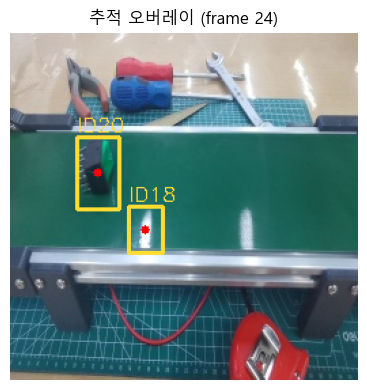

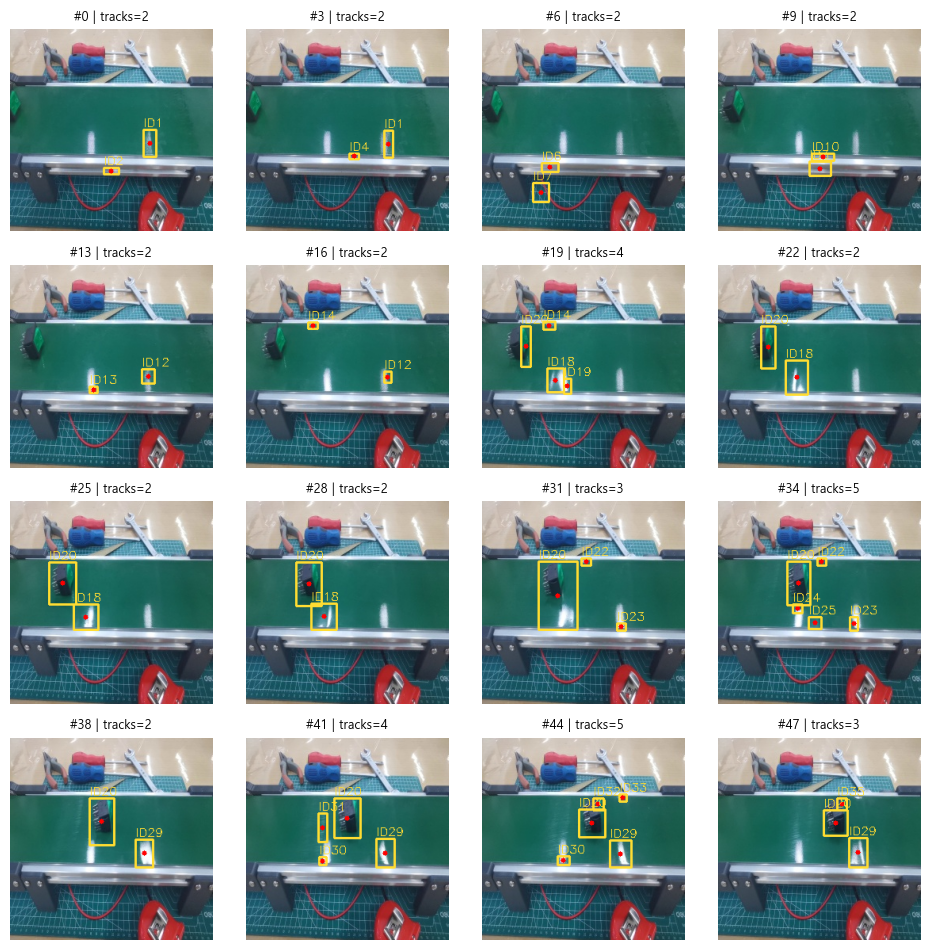

  중간 프레임 오버레이: output_tracking\predictions\03_tracking_sample.jpg


In [6]:
# =============================================================================
# Part 3 — ByteTrack 추적 (ultralytics 또는 경량 IoU tracker)
# =============================================================================
# [목적] 프레임이 바뀌어도 같은 객체에 같은 track_id를 유지합니다 (MOT).
# IPAD 데이터는 motion hybrid 검출 + SimpleByteTracker 경로를 사용합니다.


@dataclass
class Track:
    """한 프레임에서의 추적 결과 1건."""
    track_id: int
    bbox: tuple[float, float, float, float]
    confidence: float
    class_name: str
    frame_index: int


def bbox_iou(a: tuple[float, float, float, float], b: tuple[float, float, float, float]) -> float:
    """Intersection over Union — 두 bbox 겹침 비율 (0=없음, 1=완전 일치)."""
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    inter_x1, inter_y1 = max(ax1, bx1), max(ay1, by1)
    inter_x2, inter_y2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0.0, inter_x2 - inter_x1), max(0.0, inter_y2 - inter_y1)
    inter = iw * ih
    if inter <= 0:
        return 0.0
    area_a = (ax2 - ax1) * (ay2 - ay1)
    area_b = (bx2 - bx1) * (by2 - by1)
    return inter / max(area_a + area_b - inter, 1e-6)


class SimpleByteTracker:
    """ByteTrack 아이디어: 고신뢰 매칭 후 저신뢰 잔여 검출 2차 매칭."""

    def __init__(self, iou_thresh: float = 0.3, max_lost: int = 8):
        self.iou_thresh = iou_thresh   # 매칭에 필요한 최소 IoU
        self.max_lost = max_lost       # 이만큼 프레임 보이지 않으면 track 삭제
        self.next_id = 1
        self.tracks: dict[int, dict] = {}

    def update(self, dets: list[Detection], frame_idx: int) -> list[Track]:
        """현재 프레임 검출을 기존 track과 IoU 매칭해 track_id를 유지·갱신합니다."""
        high = [d for d in dets if d.confidence >= 0.5]
        low = [d for d in dets if d.confidence < 0.5]
        assigned: set[int] = set()
        outputs: list[Track] = []

        def _match(pool: list[Detection]):
            nonlocal outputs
            for det in pool:
                best_id, best_iou = None, 0.0
                for tid, st in self.tracks.items():
                    if tid in assigned:
                        continue
                    iou = bbox_iou(st["bbox"], det.bbox)
                    if iou > best_iou:
                        best_iou, best_id = iou, tid
                if best_id is not None and best_iou >= self.iou_thresh:
                    assigned.add(best_id)
                    self.tracks[best_id] = {"bbox": det.bbox, "lost": 0, "cls": det.class_name, "conf": det.confidence}
                    outputs.append(Track(best_id, det.bbox, det.confidence, det.class_name, frame_idx))
                else:
                    tid = self.next_id
                    self.next_id += 1
                    self.tracks[tid] = {"bbox": det.bbox, "lost": 0, "cls": det.class_name, "conf": det.confidence}
                    assigned.add(tid)
                    outputs.append(Track(tid, det.bbox, det.confidence, det.class_name, frame_idx))

        _match(high)   # 고신뢰 검출 우선 매칭
        _match(low)    # 저신뢰도 매칭 → occlusion에 강함

        for tid in list(self.tracks.keys()):
            if tid not in assigned:
                self.tracks[tid]["lost"] += 1
                if self.tracks[tid]["lost"] > self.max_lost:
                    del self.tracks[tid]
        return outputs


def track_objects_bytetrack_ultra(frames: list[np.ndarray]) -> list[list[Track]]:
    """ultralytics 내장 model.track + ByteTrack 사용."""
    model = get_yolo_model()
    if model is None:
        return []
    all_tracks: list[list[Track]] = []
    for i, frame in enumerate(frames):
        res = model.track(
            frame,
            persist=True,
            tracker=TRACKER_NAME,
            conf=YOLO_CONF,
            iou=YOLO_IOU,
            verbose=False,
        )[0]
        frame_tracks: list[Track] = []
        if res.boxes is not None and res.boxes.id is not None:
            names = res.names
            for box in res.boxes:
                if box.id is None:
                    continue
                tid = int(box.id.item())
                cls_id = int(box.cls.item())
                xyxy = box.xyxy[0].cpu().numpy().tolist()
                frame_tracks.append(Track(
                    track_id=tid,
                    bbox=(xyxy[0], xyxy[1], xyxy[2], xyxy[3]),
                    confidence=float(box.conf.item()),
                    class_name=names.get(cls_id, str(cls_id)),
                    frame_index=i,
                ))
        all_tracks.append(frame_tracks)
    return all_tracks


def track_objects_simple(frames: list[np.ndarray]) -> list[list[Track]]:
    """motion hybrid 검출 + SimpleByteTracker — IPAD·YOLO 폴백 공통 경로."""
    tracker = SimpleByteTracker()
    all_tracks: list[list[Track]] = []
    prev_gray = None
    for i, frame in enumerate(frames):
        next_gray = _gray_blur(frames[i + 1]) if i + 1 < len(frames) else None
        dets, prev_gray = detect_objects_hybrid(frame, prev_gray, next_gray=next_gray)
        all_tracks.append(tracker.update(dets, i))
    return all_tracks


def track_objects_bytetrack(frames: list[np.ndarray]) -> list[list[Track]]:
    """데이터 소스·YOLO 가용성에 따라 추적 엔진을 자동 선택."""
    if source_label == "IPAD":
        print("[Part 3] IPAD — motion hybrid 추적 (컨베이어 부품)")
        return track_objects_simple(frames)
    if HAS_YOLO:
        ultra = track_objects_bytetrack_ultra(frames)
        total = sum(len(t) for t in ultra)
        if total >= MIN_TRACK_HITS:
            return ultra
    return track_objects_simple(frames)


def bbox_center(bbox: tuple[float, float, float, float]) -> tuple[float, float]:
    """bbox 중심 좌표 — 속도·구역 판정에 사용."""
    x1, y1, x2, y2 = bbox
    return (0.5 * (x1 + x2), 0.5 * (y1 + y2))


def draw_tracks(frame_bgr: np.ndarray, tracks: list[Track]) -> np.ndarray:
    """track_id·중심점을 프레임 위에 오버레이."""
    vis = frame_bgr.copy()
    for t in tracks:
        x1, y1, x2, y2 = map(int, t.bbox)
        color = (50, 220, 255)
        cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)
        cv2.putText(vis, f"ID{t.track_id}", (x1, max(14, y1 - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
        cx, cy = bbox_center(t.bbox)
        cv2.circle(vis, (int(cx), int(cy)), 3, (0, 0, 255), -1)
    return vis


t0 = time.perf_counter()
track_series = track_objects_bytetrack(frames_bgr)
track_elapsed = time.perf_counter() - t0
print(f"[Part 3] 추적 완료 | 프레임 {len(track_series)} | 총 track-box {sum(len(x) for x in track_series)} | {track_elapsed:.2f}s")

mid = len(frames_bgr) // 2
vis_mid = draw_tracks(frames_bgr[mid], track_series[mid])
out_mid = PRED_DIR / "03_tracking_sample.jpg"
write_image_bgr(out_mid, vis_mid)
show_image_bgr(vis_mid, title=f"추적 오버레이 (frame {mid})")
strip_idx = pick_timeline_indices(len(frames_bgr), n_show=16)
strip_vis = [draw_tracks(frames_bgr[i], track_series[i]) for i in strip_idx]
strip_titles = [f"#{i} | tracks={len(track_series[i])}" for i in strip_idx]
show_images_grid_bgr(strip_vis, titles=strip_titles, ncols=4, figsize_per_col=2.4)
print(f"  중간 프레임 오버레이: {out_mid}")


## Part 4 — 설비 동작 상태 분석

 **이상 행동 감지 관제 시나리오**를 설비에 맞게 적용합니다.

| 신호 | 의미 |
|------|------|
| **Track Velocity** | 부품/검출체 이동 속도 → 가동 vs 정지 |
| **Zone Violation** | `operation_zone` 이탈 → 임계 구역 이상 |
| **Motion Z-score** | 02·07과 동일한 동작 급변 신호 |

상태 라벨: `RUNNING` · `IDLE` · `ANOMALY`


### 기술 설명 — 설비 동작 상태 분류

검출·추적만으로는 “설비가 정상인가?”를 알기 어렵습니다. 여기서는 **규칙 기반 상태 머신**으로 프레임마다 라벨을 붙입니다.

| 상태 | 의미 | 대표 조건 |
|------|------|-----------|
| `RUNNING` | 가동 중 | 추적 속도 ≥ `VELOCITY_RUN_THRESH` |
| `IDLE` | 대기·저활동 | 추적 속도 ≤ `VELOCITY_IDLE_THRESH` |
| `ANOMALY` | 이상 후보 | 구역 연속 이탈 또는 motion z-score 급등 |

**motion z-score**  
초반 몇 프레임의 motion 평균·표준편차를 기준으로, 현재 프레임이 얼마나 **통계적으로 튀는지** 나타냅니다. 02·07번의 z-score 아이디어와 같습니다.

`FrameState` 한 줄이 곧 **한 프레임의 관제 레코드**이며, 이후 요약·manifest·대시보드의 입력이 됩니다.

### 초보자를 위한 기술 이해

검출·추적 결과만으로는 “설비가 정상인가?”를 알기 어렵습니다. 여기서는 규칙으로 **동작 상태 라벨**을 붙입니다.
- `RUNNING`: 추적 대상 속도가 가동 임계값 이상 — 부품이 실제로 움직이는 구간입니다.
- `IDLE`: 속도가 낮아 대기·저활동 상태로 보이는 구간입니다.
- `ANOMALY`: 허용 구역 이탈이 반복되거나 motion z-score가 급등한 **이상 후보** 구간입니다.
- **Velocity**: 바운딩 박스 중심이 프레임마다 얼마나 이동했는지로 가동·정지를 나눕니다.
- **Z-score**: 초반 프레임의 평균·표준편차 대비 현재 움직임이 얼마나 통계적으로 튀는지 나타냅니다.
`FrameState` 한 줄이 곧 한 프레임의 관제 레코드이며, 요약·대시보드·manifest의 공통 입력입니다.


In [7]:
# =============================================================================
# Part 4 — 구역 · 속도 · motion 기반 설비 동작 상태 분류
# =============================================================================
# [목적] 추적 궤적 + motion 시계열로 프레임마다 RUNNING/IDLE/ANOMALY 라벨 부여


@dataclass
class FrameState:
    """한 프레임의 설비 상태 스냅샷 — manifest·대시보드의 기본 레코드."""
    frame_index: int
    operation_state: str
    max_velocity: float
    motion_energy: float
    motion_z: float
    zone_violations: list[str]
    active_track_ids: list[int]


def zone_to_pixels(zone: tuple[float, float, float, float], w: int, h: int) -> tuple[int, int, int, int]:
    """비율 ROI → 픽셀 좌표."""
    x1, y1, x2, y2 = zone
    return int(x1 * w), int(y1 * h), int(x2 * w), int(y2 * h)


def point_in_zone(px: float, py: float, zone_xyxy: tuple[int, int, int, int]) -> bool:
    """점 (px, py)가 사각형 zone 안에 있는지 판정."""
    x1, y1, x2, y2 = zone_xyxy
    return x1 <= px <= x2 and y1 <= py <= y2


def compute_motion_energy(frames: list[np.ndarray]) -> np.ndarray:
    """인접 프레임 그레이 차이 평균 → 동작 강도 시계열."""
    energies = [0.0]
    for i in range(1, len(frames)):
        g0 = cv2.cvtColor(frames[i - 1], cv2.COLOR_BGR2GRAY).astype(np.float32)
        g1 = cv2.cvtColor(frames[i], cv2.COLOR_BGR2GRAY).astype(np.float32)
        energies.append(float(np.mean(np.abs(g1 - g0))))
    return np.array(energies, dtype=np.float32)


def motion_zscore(series: np.ndarray, baseline_n: int = 6) -> np.ndarray:
    """초반 baseline 대비 z-score — 값이 크면 평소와 다른 움직임."""
    base = series[:baseline_n]
    mu, sigma = float(base.mean()), float(base.std()) if len(base) > 1 else 1.0
    sigma = max(sigma, 1e-3)
    return (series - mu) / sigma


def compute_track_velocity(track_series: list[list[Track]]) -> dict[int, list[float]]:
    """track_id별 bbox 중심 이동 거리(px/frame) 리스트."""
    history: dict[int, list[tuple[int, tuple[float, float]]]] = defaultdict(list)
    for frame_tracks in track_series:
        for t in frame_tracks:
            history[t.track_id].append((t.frame_index, bbox_center(t.bbox)))
    velocities: dict[int, list[float]] = defaultdict(list)
    for tid, pts in history.items():
        for i in range(1, len(pts)):
            f0, (x0, y0) = pts[i - 1]
            f1, (x1, y1) = pts[i]
            if f1 != f0 + 1:
                continue
            dist = float(np.hypot(x1 - x0, y1 - y0))
            velocities[tid].append(dist)
    return velocities


def check_zone_violations(tracks: list[Track], w: int, h: int) -> list[str]:
    """motion_part·person이 operation_zone 밖에 있으면 위반 목록에 추가."""
    zones_px = {name: zone_to_pixels(z, w, h) for name, z in EQUIPMENT_ZONES.items()}
    op = zones_px["operation_zone"]
    violations: list[str] = []
    for t in tracks:
        cx, cy = bbox_center(t.bbox)
        if t.class_name in {"motion_part", "person"} and not point_in_zone(cx, cy, op):
            violations.append(f"ID{t.track_id}:{t.class_name}")
    return violations


def classify_equipment_state(
    max_vel: float,
    motion_z: float,
    zone_violations: list[str],
    violation_streak: int,
) -> str:
    """속도·motion z·구역 이탈 연속 횟수로 RUNNING/IDLE/ANOMALY 분류."""
    if violation_streak >= ZONE_VIOLATION_FRAMES or motion_z >= MOTION_Z_ANOMALY:
        return "ANOMALY"
    if max_vel >= VELOCITY_RUN_THRESH:
        return "RUNNING"
    if max_vel <= VELOCITY_IDLE_THRESH:
        return "IDLE"
    return "RUNNING" if max_vel > VELOCITY_IDLE_THRESH else "IDLE"


motion = compute_motion_energy(frames_bgr)
motion_z = motion_zscore(motion)
velocities = compute_track_velocity(track_series)

frame_states: list[FrameState] = []
violation_streak = 0
h, w = frames_bgr[0].shape[:2]

for i, tracks in enumerate(track_series):
    max_vel = 0.0
    for t in tracks:
        vlist = velocities.get(t.track_id, [])
        if vlist:
            max_vel = max(max_vel, vlist[-1])
    zv = check_zone_violations(tracks, w, h)
    violation_streak = violation_streak + 1 if zv else 0
    state = classify_equipment_state(max_vel, float(motion_z[i]), zv, violation_streak)
    frame_states.append(FrameState(
        frame_index=i,
        operation_state=state,
        max_velocity=max_vel,
        motion_energy=float(motion[i]),
        motion_z=float(motion_z[i]),
        zone_violations=zv,
        active_track_ids=[t.track_id for t in tracks],
    ))

state_counts = defaultdict(int)
for fs in frame_states:
    state_counts[fs.operation_state] += 1
print("[Part 4] 동작 상태 분포:", dict(state_counts))


[Part 4] 동작 상태 분포: {'RUNNING': 46, 'IDLE': 2}


## Part 5 — 상황 요약 에이전트 (Global Reasoning)

교재 **Video-LLaVA** 단계의 실습용 경량 대체: 추적·상태 이벤트를 **한국어 관제 리포트**로 변환합니다.

- `ANOMALY` 프레임에서 요약 생성 (교재: VLM 에이전트 즉시 활성화)
- 실무에서는 대표 키프레임 + Video-LLaVA API 연동 (05번 VLM 노트북 참고)


### 기술 설명 — 상황 요약 에이전트

교재의 **Video-LLaVA(Global Reasoning)** 단계는 영상 맥락을 자연어로 설명합니다. 본 실습은 경량 **템플릿 에이전트**로 같은 역할을 흉내 냅니다.

**언제 리포트를 만들나?**  
- `ANOMALY` 프레임: 즉시 (교재의 “VLM 에이전트 활성화”에 해당)  
- 그 외: 전체 길이의 약 1/6 간격으로 샘플링해 타임라인 요약 확보

실무에서는 대표 키프레임 이미지 + Video-LLaVA API로 문장 품질을 높일 수 있습니다. 05번 VLM 노트북과 연동하면 좋습니다.

### 초보자를 위한 기술 이해

교재의 **Video-LLaVA(VLM)** 는 영상 맥락을 AI가 자연어로 설명하는 무거운 단계입니다. 본 실습은 같은 자리를 **템플릿 에이전트**가 대신합니다.
- 템플릿 방식: 추적 ID, 상태 라벨, 구역 이탈 같은 **구조화된 이벤트**를 정해진 문장 패턴으로 조합합니다.
- VLM 방식: 대표 키프레임 이미지를 모델에 넣어 더 풍부하고 유연한 설명을 생성합니다.
- `ANOMALY` 프레임에서는 즉시 리포트를 만들고, 그 외에는 일정 간격으로 타임라인 요약을 남깁니다.
템플릿은 GPU·API 없이도 **관제 문장 파이프라인**을 끝까지 연결해 보는 데 적합합니다.
생성된 `SituationReport`는 Part 6 벡터 DB에 저장되어 이후 자연어 검색의 재료가 됩니다.
PoC 단계에서는 템플릿으로 파이프라인을 빠르게 검증하고, 실무에서는 05번 VLM 노트북과 API 연동으로 품질을 높입니다.


In [8]:
# =============================================================================
# Part 5 — 상황 요약 에이전트
# =============================================================================
# [목적] FrameState를 사람이 읽을 수 있는 한국어 상황 리포트로 변환합니다.


@dataclass
class SituationReport:
    """한 프레임(또는 이벤트)에 대한 자연어 요약 레코드."""
    report_id: str
    frame_index: int
    timestamp_sec: float
    operation_state: str
    summary_ko: str
    details: dict


def generate_situation_report(fs: FrameState, fps: float = FPS_ASSUMED) -> SituationReport:
    """동작 상태에 따라 한국어 요약 문장을 생성합니다."""
    ts = fs.frame_index / max(fps, 1e-3)
    if fs.operation_state == "ANOMALY":
        if fs.zone_violations:
            body = (
                f"프레임 {fs.frame_index}({ts:.1f}s): 설비 작업 구역 이탈 감지. "
                f"추적 대상 {', '.join(fs.zone_violations)}이(가) operation_zone 밖으로 이동했습니다."
            )
        else:
            body = (
                f"프레임 {fs.frame_index}({ts:.1f}s): 동작 강도 급변(motion z={fs.motion_z:.2f}). "
                "설비 사이클 이상 또는 과도 진동 가능성이 있습니다."
            )
    elif fs.operation_state == "RUNNING":
        body = (
            f"프레임 {fs.frame_index}({ts:.1f}s): 정상 가동 중. "
            f"최대 추적 속도 {fs.max_velocity:.1f}px/frame, 활성 ID {fs.active_track_ids}."
        )
    else:
        body = (
            f"프레임 {fs.frame_index}({ts:.1f}s): 저활동/대기 상태. "
            f"추적 속도 {fs.max_velocity:.1f}px/frame."
        )
    return SituationReport(
        report_id=str(uuid.uuid4())[:8],
        frame_index=fs.frame_index,
        timestamp_sec=ts,
        operation_state=fs.operation_state,
        summary_ko=body,
        details={
            "motion_z": fs.motion_z,
            "motion_energy": fs.motion_energy,
            "zone_violations": fs.zone_violations,
            "active_track_ids": fs.active_track_ids,
        },
    )


reports: list[SituationReport] = []
for fs in frame_states:
    # 이상 프레임은 전부, 정상은 클립을 대표하는 간격으로 샘플링
    if fs.operation_state == "ANOMALY" or fs.frame_index % max(1, len(frame_states) // 6) == 0:
        reports.append(generate_situation_report(fs))

print(f"[Part 5] 상황 리포트 {len(reports)}건 생성")
for r in reports[:3]:
    print(" -", r.summary_ko[:90], "...")


[Part 5] 상황 리포트 6건 생성
 - 프레임 0(0.0s): 정상 가동 중. 최대 추적 속도 10.5px/frame, 활성 ID [1, 2]. ...
 - 프레임 8(0.8s): 정상 가동 중. 최대 추적 속도 10.0px/frame, 활성 ID [2, 10]. ...
 - 프레임 16(1.6s): 정상 가동 중. 최대 추적 속도 1.5px/frame, 활성 ID [12, 14]. ...


## Part 6 — ChromaDB 저장 · 시맨틱 관제 검색

교재 **Storage & Search**: 요약 텍스트를 Vector DB에 저장하고 자연어로 검색합니다.


### 기술 설명 — 벡터 DB · 시맨틱 검색

**시맨틱 검색**은 키워드가 정확히 일치하지 않아도 **의미가 비슷한** 리포트를 찾습니다. 예: “컨베이어 멈춤” 질의 → “저활동/대기 상태” 리포트 매칭.

| 구성요소 | 설명 |
|----------|------|
| `_hash_embed` | 교육용 결정적 벡터 (실무는 sentence-transformers 등) |
| `InMemoryReportIndex` | ChromaDB 없이 코사인 유사도 검색 |
| ChromaDB | `USE_CHROMA=1` 환경 변수 설정 시 영속 저장 |

벡터 DB에 쌓인 요약은 나중에 **“지난주 구역 이탈 사건 검색”** 같은 운영 질의에 활용됩니다.

### 초보자를 위한 기술 이해

**벡터 DB**는 문장을 고차원 숫자 벡터(임베딩)로 바꿔 저장하는 데이터베이스입니다.
- 일반 검색은 “정지”라는 단어가 정확히 있어야 찾지만, **시맨틱 검색**은 “컨베이어 멈춤”과 “저활동 대기”처럼 표현이 달라도 의미가 가까우면 매칭합니다.
- 코사인 유사도로 질의 문장과 저장된 리포트 벡터가 얼마나 비슷한지 점수를 냅니다.
- ChromaDB가 없으면 `InMemoryReportIndex`로 메모리에서 같은 원리를 시연합니다.
교육용 `_hash_embed`는 결정적 벡터를 쓰며, 실무에서는 sentence-transformers 같은 **전용 임베딩 모델**로 교체합니다.
`USE_CHROMA=1`이면 `output_tracking/chroma_db/`에 리포트가 영속 저장됩니다.
관제 로그가 쌓이면 “지난주 구역 이탈 사건”, “이상 z-score 급등 구간” 같은 운영 질의에 활용할 수 있습니다.


In [9]:
# =============================================================================
# Part 6 — ChromaDB 인덱싱 · 시맨틱 검색
# =============================================================================
# [목적] 상황 요약 문장을 벡터로 저장하고, 자연어 질의로 유사 리포트를 검색합니다.


def _hash_embed(text: str, dim: int = EMBED_DIM) -> list[float]:
  """경량 임베딩: 교육용 deterministic hash vector (실무는 sentence-transformers 권장)."""
  rng = np.random.default_rng(abs(hash(text)) % (2**32))
  vec = rng.standard_normal(dim).astype(np.float32)
  vec /= np.linalg.norm(vec) + 1e-8
  return vec.tolist()


class InMemoryReportIndex:
    """ChromaDB 사용 불가 시 교육용 인메모리 벡터 검색."""

    def __init__(self, reports: list[SituationReport]):
        self.reports = reports
        self.embs = np.array([_hash_embed(r.summary_ko) for r in reports], dtype=np.float32)

    def query(self, query: str, top_k: int = 3) -> list[dict]:
        """쿼리 문장과 코사인 유사도가 높은 리포트 top_k 반환."""
        if not self.reports:
            return []
        q = np.array(_hash_embed(query), dtype=np.float32)
        sims = self.embs @ q
        order = np.argsort(-sims)[:top_k]
        hits = []
        for i in order:
            r = self.reports[int(i)]
            hits.append({
                "id": r.report_id,
                "document": r.summary_ko,
                "metadata": {
                    "frame_index": r.frame_index,
                    "operation_state": r.operation_state,
                    "timestamp_sec": r.timestamp_sec,
                },
                "distance": float(1.0 - sims[i]),
            })
        return hits


def index_reports_chroma(reports: list[SituationReport]):
    """ChromaDB 연동 예시. 일부 Windows 환경에서 native crash가 있어 기본은 인메모리 인덱스."""
    use_chroma = HAS_CHROMA and os.environ.get("USE_CHROMA", "0") == "1"
    if not use_chroma:
        print("[Part 6] 인메모리 벡터 검색 (ChromaDB는 USE_CHROMA=1 설정 시 활성화)")
        return InMemoryReportIndex(reports)
    try:
        client = chromadb.PersistentClient(path=str(CHROMA_DIR))
        try:
            client.delete_collection(CHROMA_COLLECTION)
        except Exception:
            pass
        col = client.create_collection(name=CHROMA_COLLECTION, metadata={"hnsw:space": "cosine"})
        ids, docs, embs, metas = [], [], [], []
        for r in reports:
            ids.append(r.report_id)
            docs.append(r.summary_ko)
            embs.append(_hash_embed(r.summary_ko))
            metas.append({
                "frame_index": r.frame_index,
                "operation_state": r.operation_state,
                "timestamp_sec": r.timestamp_sec,
            })
        if ids:
            col.add(ids=ids, documents=docs, embeddings=embs, metadatas=metas)
        print(f"[Part 6] ChromaDB 저장 {len(ids)}건 -> {CHROMA_DIR}")
        return col
    except Exception as exc:
        print(f"[Part 6] ChromaDB 오류, 인메모리 폴백: {exc}")
        return InMemoryReportIndex(reports)


def search_reports(collection, query: str, top_k: int = 3) -> list[dict]:
    """Chroma 컬렉션 또는 InMemoryReportIndex에서 유사 리포트 검색."""
    if collection is None:
        return []
    if isinstance(collection, InMemoryReportIndex):
        return collection.query(query, top_k=top_k)
    qemb = _hash_embed(query)
    res = collection.query(query_embeddings=[qemb], n_results=min(top_k, max(1, len(reports))))
    hits = []
    for i in range(len(res["ids"][0])):
        hits.append({
            "id": res["ids"][0][i],
            "document": res["documents"][0][i],
            "metadata": res["metadatas"][0][i],
            "distance": res["distances"][0][i] if res.get("distances") else None,
        })
    return hits


chroma_col = index_reports_chroma(reports)
queries = ["설비 구역 이탈", "정상 가동", "동작 급변 이상"]
for q in queries:
    hits = search_reports(chroma_col, q, top_k=2)
    print(f"\n[검색] '{q}'")
    for h in hits:
        print(f"  · ({h['metadata'].get('operation_state')}) {h['document'][:75]}...")


[Part 6] 인메모리 벡터 검색 (ChromaDB는 USE_CHROMA=1 설정 시 활성화)

[검색] '설비 구역 이탈'
  · (RUNNING) 프레임 8(0.8s): 정상 가동 중. 최대 추적 속도 10.0px/frame, 활성 ID [2, 10]....
  · (RUNNING) 프레임 16(1.6s): 정상 가동 중. 최대 추적 속도 1.5px/frame, 활성 ID [12, 14]....

[검색] '정상 가동'
  · (RUNNING) 프레임 40(4.0s): 정상 가동 중. 최대 추적 속도 7.4px/frame, 활성 ID [29, 20]....
  · (RUNNING) 프레임 32(3.2s): 정상 가동 중. 최대 추적 속도 7.4px/frame, 활성 ID [20, 23]....

[검색] '동작 급변 이상'
  · (RUNNING) 프레임 40(4.0s): 정상 가동 중. 최대 추적 속도 7.4px/frame, 활성 ID [29, 20]....
  · (RUNNING) 프레임 24(2.4s): 정상 가동 중. 최대 추적 속도 7.4px/frame, 활성 ID [18, 20]....


## Part 7 — 관제 대시보드 · MOT 지표 · manifest

교재 성능 평가 지표를 실습 규모로 측정합니다.

| 영역 | 지표 |
|------|------|
| MOT | ID Switches, Track Continuity, 처리 FPS |
| 관제 | 상태 타임라인, 이벤트 바 차트, 구역 오버레이 |


### 기술 설명 — 관제 대시보드 · 성능 지표

**대시보드**는 관제원이 한눈에 보는 화면입니다. 파이 차트(상태 비율), 막대(프레임별 상태), 꺾은선(motion·track 수)으로 구성됩니다.

**MOT 성능 지표**

| 지표 | 의미 |
|------|------|
| ID Switches | 주요 추적 대상 ID가 바뀐 횟수 — 낮을수록 안정적 |
| Track Continuity | track ID가 평균 몇 프레임 유지되었는지 |
| Processing FPS | 초당 처리 프레임 수 — 실시간 관제 여유 판단 |

`tracking_manifest.json`은 08번 통합 manifest에 넣을 **프레임별 추적·상태·요약**의 표준 JSON입니다.

### 초보자를 위한 기술 이해

**대시보드**는 숫자와 차트로 한 세션의 관제 결과를 한눈에 보여 주는 화면입니다.
- 상태 파이·막대 차트: `RUNNING` / `IDLE` / `ANOMALY` 비율과 시간 흐름을 시각화합니다.
- **ID Switches**: 주요 추적 대상의 ID가 중간에 바뀐 횟수입니다. 많으면 가림·검출 누락으로 궤적이 끊긴 것입니다.
- **Track Continuity**: 하나의 ID가 평균 몇 프레임 동안 유지되었는지입니다. 높을수록 추적이 안정적입니다.
- **Processing FPS**: 초당 처리 프레임 수로, 실시간 관제에 GPU·알고리즘 여유가 있는지 판단합니다.
구역 오버레이와 motion 꺾은선은 **이상 구간이 언제·어디서** 발생했는지 교차 확인합니다.
지표는 정답(GT) 없이도 추적 품질과 처리 속도를 모니터링하는 실습용 기준입니다.


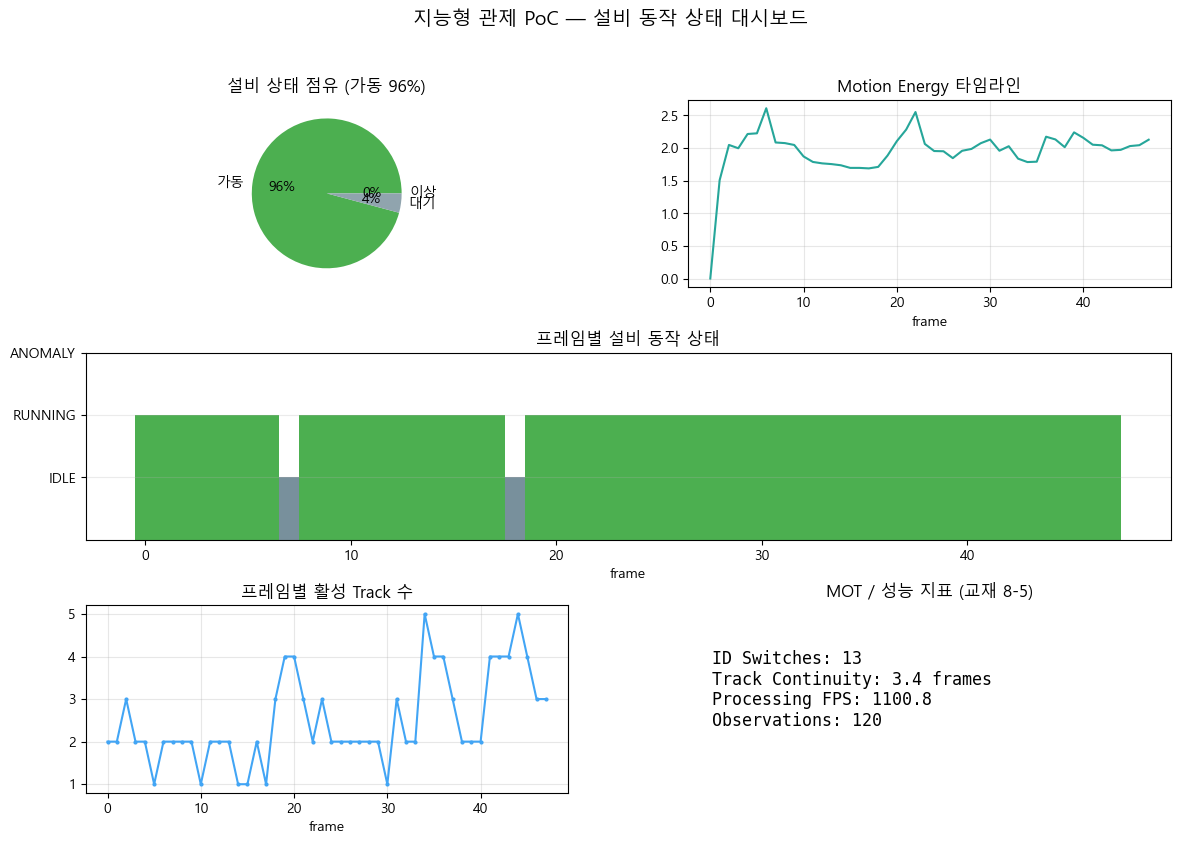

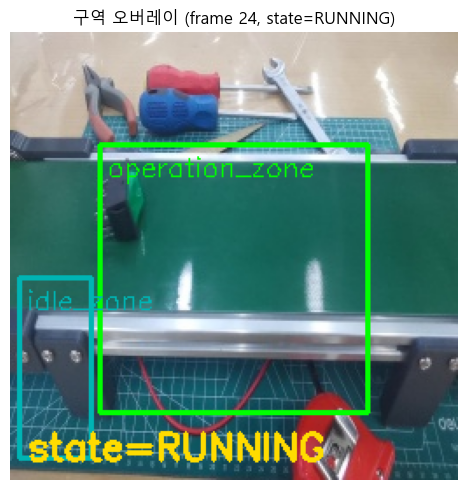

[Part 7] 대시보드 → output_tracking\figures\07_control_dashboard.png
[Part 7] 구역 오버레이 → output_tracking\predictions\07_zone_overlay.jpg
[Part 7] manifest → output_tracking\tracking_manifest.json
[MOT 지표] {
  "num_frames": 48,
  "id_switches": 13,
  "track_continuity_mean": 3.4285714285714284,
  "processing_fps": 1100.776046657455,
  "total_track_observations": 120
}

[상황 요약 샘플]
  · (RUNNING) 프레임 0(0.0s): 정상 가동 중. 최대 추적 속도 10.5px/frame, 활성 ID [1, 2].
  · (RUNNING) 프레임 8(0.8s): 정상 가동 중. 최대 추적 속도 10.0px/frame, 활성 ID [2, 10].
  · (RUNNING) 프레임 16(1.6s): 정상 가동 중. 최대 추적 속도 1.5px/frame, 활성 ID [12, 14].


In [10]:
# =============================================================================
# Part 7 — 대시보드 · MOT 지표 · manifest export
# =============================================================================
# [목적] 추적·상태 분류 결과를 시각화하고 JSON manifest로 보냅니다.


def count_id_switches(track_series: list[list[Track]]) -> int:
    """프레임마다 가장 큰 bbox의 track_id가 바뀐 횟수 — ID 스위치 지표."""
    last_id_by_slot: list[int | None] = []
    switches = 0
    for frame_tracks in track_series:
        if not frame_tracks:
            continue
        primary = max(frame_tracks, key=lambda t: (t.bbox[2]-t.bbox[0])*(t.bbox[3]-t.bbox[1]))
        if last_id_by_slot and last_id_by_slot[-1] is not None and primary.track_id != last_id_by_slot[-1]:
            switches += 1
        last_id_by_slot.append(primary.track_id)
    return switches


def track_continuity(track_series: list[list[Track]]) -> float:
    """track_id별 관측 프레임 수의 평균 — 연속성이 높을수록 추적 품질이 좋음."""
    lengths = defaultdict(int)
    for fts in track_series:
        for t in fts:
            lengths[t.track_id] += 1
    if not lengths:
        return 0.0
    return float(np.mean(list(lengths.values())))


def evaluate_tracking_session(track_series: list[list[Track]], elapsed_sec: float, num_frames: int) -> dict:
    """MOT·성능 지표를 한 dict로 묶어 manifest·대시보드에 사용."""
    fps_proc = num_frames / max(elapsed_sec, 1e-6)
    return {
        "num_frames": num_frames,
        "id_switches": count_id_switches(track_series),
        "track_continuity_mean": track_continuity(track_series),
        "processing_fps": fps_proc,
        "total_track_observations": sum(len(x) for x in track_series),
    }


def plot_control_dashboard(
    frame_states: list[FrameState],
    motion: np.ndarray,
    track_series: list[list[Track]],
    save_path: Path,
) -> None:
    """설비 상태·motion·track 수·MOT 지표를 한 장의 대시보드 PNG로 저장."""
    fig = plt.figure(figsize=(14, 9))
    gs = GridSpec(3, 2, figure=fig, hspace=0.35, wspace=0.25)

    idx = np.arange(len(frame_states))
    states = [fs.operation_state for fs in frame_states]
    state_map = {"RUNNING": 2, "IDLE": 1, "ANOMALY": 3}
    state_num = [state_map.get(s, 0) for s in states]

    ax0 = fig.add_subplot(gs[0, 0])
    running_ratio = states.count("RUNNING") / max(1, len(states))
    ax0.pie(
        [states.count("RUNNING"), states.count("IDLE"), states.count("ANOMALY")],
        labels=["가동", "대기", "이상"],
        autopct="%1.0f%%",
        colors=["#4caf50", "#90a4ae", "#ef5350"],
    )
    ax0.set_title(f"설비 상태 점유 (가동 {running_ratio:.0%})")

    ax1 = fig.add_subplot(gs[0, 1])
    ax1.plot(idx, motion, color="#26a69a", lw=1.5)
    ax1.set_title("Motion Energy 타임라인")
    ax1.set_xlabel("frame")
    ax1.grid(alpha=0.3)

    ax2 = fig.add_subplot(gs[1, :])
    colors = {2: "#4caf50", 1: "#78909c", 3: "#e53935"}
    ax2.bar(idx, state_num, color=[colors.get(v, "#ccc") for v in state_num], width=1.0)
    ax2.set_yticks([1, 2, 3])
    ax2.set_yticklabels(["IDLE", "RUNNING", "ANOMALY"])
    ax2.set_title("프레임별 설비 동작 상태")
    ax2.set_xlabel("frame")
    ax2.grid(axis="y", alpha=0.25)

    ax3 = fig.add_subplot(gs[2, 0])
    track_counts = [len(t) for t in track_series]
    ax3.plot(idx, track_counts, color="#42a5f5", marker="o", ms=2)
    ax3.set_title("프레임별 활성 Track 수")
    ax3.set_xlabel("frame")
    ax3.grid(alpha=0.3)

    ax4 = fig.add_subplot(gs[2, 1])
    metrics = evaluate_tracking_session(track_series, track_elapsed, len(frames_bgr))
    text = (
        f"ID Switches: {metrics['id_switches']}\n"
        f"Track Continuity: {metrics['track_continuity_mean']:.1f} frames\n"
        f"Processing FPS: {metrics['processing_fps']:.1f}\n"
        f"Observations: {metrics['total_track_observations']}"
    )
    ax4.axis("off")
    ax4.text(0.05, 0.55, text, fontsize=12, family="monospace", va="center")
    ax4.set_title("MOT / 성능 지표 (교재 8-5)")

    fig.suptitle("지능형 관제 PoC — 설비 동작 상태 대시보드", fontsize=14, y=0.98)
    fig.savefig(save_path, dpi=130, bbox_inches="tight")
    show_figure(fig)  # 노트북 셀에도 대시보드 표시 (파일 저장과 동시)
    plt.close(fig)


def draw_zones_overlay(frame_bgr: np.ndarray, frame_state: FrameState) -> np.ndarray:
    """구역 사각형 + 현재 operation_state를 프레임에 오버레이."""
    vis = frame_bgr.copy()
    h, w = vis.shape[:2]
    for name, zone in EQUIPMENT_ZONES.items():
        x1, y1, x2, y2 = zone_to_pixels(zone, w, h)
        color = (0, 255, 0) if name == "operation_zone" else (180, 180, 0)
        cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)
        cv2.putText(vis, name, (x1 + 4, y1 + 18), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    cv2.putText(
        vis,
        f"state={frame_state.operation_state}",
        (10, h - 12),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 220, 255),
        2,
    )
    return vis


def export_tracking_manifest(
    frame_states: list[FrameState],
    track_series: list[list[Track]],
    reports: list[SituationReport],
    metrics: dict,
) -> Path:
    """전체 세션 결과를 tracking_manifest.json으로 저장."""
    payload = {
        "version": "1.0",
        "dataset": source_label,
        "engine": "yolov8_bytetrack + motion_state_agent",
        "num_frames": len(frame_states),
        "equipment_zones": EQUIPMENT_ZONES,
        "metrics": metrics,
        "situation_reports": [
            {
                "report_id": r.report_id,
                "frame_index": r.frame_index,
                "timestamp_sec": r.timestamp_sec,
                "operation_state": r.operation_state,
                "summary_ko": r.summary_ko,
                "details": r.details,
            }
            for r in reports
        ],
        "frames": [],
    }
    for i, fs in enumerate(frame_states):
        payload["frames"].append({
            "frame_index": fs.frame_index,
            "image_path": str(frame_paths[i]) if i < len(frame_paths) else None,
            "operation_state": fs.operation_state,
            "max_velocity": fs.max_velocity,
            "motion_energy": fs.motion_energy,
            "motion_z": fs.motion_z,
            "zone_violations": fs.zone_violations,
            "tracks": [
                {
                    "track_id": t.track_id,
                    "bbox": list(t.bbox),
                    "class_name": t.class_name,
                    "confidence": t.confidence,
                }
                for t in track_series[i]
            ],
        })
    MANIFEST_PATH.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
    return MANIFEST_PATH


metrics = evaluate_tracking_session(track_series, track_elapsed, len(frames_bgr))
dashboard_path = FIG_DIR / "07_control_dashboard.png"
plot_control_dashboard(frame_states, motion, track_series, dashboard_path)

anomaly_idx = next((fs.frame_index for fs in frame_states if fs.operation_state == "ANOMALY"), len(frames_bgr)//2)
zone_vis = draw_zones_overlay(frames_bgr[anomaly_idx], frame_states[anomaly_idx])
zone_path = PRED_DIR / "07_zone_overlay.jpg"
write_image_bgr(zone_path, zone_vis)
show_image_bgr(
    zone_vis,
    title=f"구역 오버레이 (frame {anomaly_idx}, state={frame_states[anomaly_idx].operation_state})",
    figsize=(7.0, 5.0),
)

manifest_path = export_tracking_manifest(frame_states, track_series, reports, metrics)
print(f"[Part 7] 대시보드 → {dashboard_path}")
print(f"[Part 7] 구역 오버레이 → {zone_path}")
print(f"[Part 7] manifest → {manifest_path}")
print("[MOT 지표]", json.dumps(metrics, ensure_ascii=False, indent=2))
if reports:
    print("\n[상황 요약 샘플]")
    for r in reports[:3]:
        print(f"  · ({r.operation_state}) {r.summary_ko[:100]}")


### 정리 · 08번 통합 manifest 연동

| 산출물 | 경로 |
|--------|------|
| **원본 시각화** | `output_tracking/figures/01_source_overview.png` |
| 추적 오버레이 | `output_tracking/predictions/` |
| 관제 대시보드 | `output_tracking/figures/07_control_dashboard.png` |
| 상황 리포트 DB | `output_tracking/chroma_db/` |
| 추적 manifest | `output_tracking/tracking_manifest.json` |

**다음 단계**
- 08번 `MANIFEST_SOURCES`에 `tracking_manifest.json` 추가 후 `operation_state`·`motion_z` 신호 병합
- 05번 Video-LLaVA로 `ANOMALY` 키프레임 자연어 요약 고도화
- 실 CCTV RTSP → decord 스트림 입력으로 PoC 확장

> 교재 평가 지표: 실 GT가 없으므로 **ID Switches·Continuity·FPS** 로 MOT 품질을 모니터링하고, VLM 연동 시 BLEU/ROUGE를 추가하세요.


### 초보자를 위한 기술 이해

**manifest export**는 프레임마다 검출·추적·상태·요약을 담은 **표준 JSON 파일**을 남기는 단계입니다.
- `tracking_manifest.json`에는 프레임 인덱스, track ID, bbox, `operation_state`, motion z-score, 리포트 문장 등이 기록됩니다.
- 그림·DB와 달리 JSON은 다른 프로그램이 읽기 쉬운 **기계 친화적 산출물**입니다.
- 08번 통합 manifest의 `MANIFEST_SOURCES`에 추가하면 pose·VLM·tracking 신호를 한 타임라인으로 병합할 수 있습니다.
PNG 대시보드는 사람이 보기 좋고, manifest는 **배치 재분석·규칙 엔진·다른 노트북**이 읽기 좋습니다.
한 번의 PoC 결과를 재현·비교·배치 분석할 때 manifest가 데이터 계약(contract) 역할을 합니다.
다음 단계로 RTSP 실시간 입력이나 Video-LLaVA 요약 고도화를 붙일 때도 manifest가 중간 저장 형식이 됩니다.
